In [3]:
%%capture
!pip install --force-reinstall numpy scikit-learn
!pip install fiftyone

# Dataset download 

In [ ]:
# PPE dataset download 
dataset_url = "https://github.com/ultralytics/assets/releases/download/v0.0.0/construction-ppe.zip"
!wget -O dataset.zip $dataset_url
!unzip -o dataset.zip -d datasets/construction-ppe
!rm dataset.zip

In [ ]:
%%writefile ./datasets/construction-ppe/dataset.yaml
path: . # dataset root dir
train: images/train # train images (relative to 'path') 1132 images
val: images/val # val images (relative to 'path') 143 images
test: images/test # test images (relative to 'path') 141 images

# Classes
names:
  0: helmet
  1: gloves
  2: vest
  3: boots
  4: goggles
  5: none
  6: Person
  7: no_helmet
  8: no_goggle
  9: no_gloves
  10: no_boots

# Load the dataset

In [ ]:
import fiftyone as fo

# Delete existing dataset if it exists
if "construction-ppe" in fo.list_datasets():
    fo.delete_dataset("construction-ppe")

# Load all splits of the YOLO dataset
dataset = fo.Dataset("construction-ppe")

for split in ["train", "val", "test"]:
    dataset.add_dir(
        dataset_dir="datasets/construction-ppe",
        dataset_type=fo.types.YOLOv5Dataset,
        yaml_path="dataset.yaml",
        split=split,
        tags=split,
    )


 100% |███████████████| 1132/1132 [1.5s elapsed, 0s remaining, 780.5 samples/s]         
 100% |█████████████████| 143/143 [214.0ms elapsed, 0s remaining, 668.3 samples/s]      
 100% |█████████████████| 141/141 [168.1ms elapsed, 0s remaining, 842.3 samples/s]    
Name:        construction-ppe
Media type:  image
Num samples: 1416
Persistent:  False
Tags:        []
Sample fields:
    id:               fiftyone.core.fields.ObjectIdField
    filepath:         fiftyone.core.fields.StringField
    tags:             fiftyone.core.fields.ListField(fiftyone.core.fields.StringField)
    metadata:         fiftyone.core.fields.EmbeddedDocumentField(fiftyone.core.metadata.ImageMetadata)
    created_at:       fiftyone.core.fields.DateTimeField
    last_modified_at: fiftyone.core.fields.DateTimeField
    ground_truth:     fiftyone.core.fields.EmbeddedDocumentField(fiftyone.core.labels.Detections)


In [2]:
import fiftyone as fo
dataset = fo.load_dataset("construction-ppe")

In [3]:
print(dataset.summary())

Name:        construction-ppe
Media type:  image
Num samples: 1416
Persistent:  False
Tags:        []
Sample fields:
    id:                      fiftyone.core.fields.ObjectIdField
    filepath:                fiftyone.core.fields.StringField
    tags:                    fiftyone.core.fields.ListField(fiftyone.core.fields.StringField)
    metadata:                fiftyone.core.fields.EmbeddedDocumentField(fiftyone.core.metadata.ImageMetadata)
    created_at:              fiftyone.core.fields.DateTimeField
    last_modified_at:        fiftyone.core.fields.DateTimeField
    ground_truth:            fiftyone.core.fields.EmbeddedDocumentField(fiftyone.core.labels.Detections)
    coco_predictions:        fiftyone.core.fields.EmbeddedDocumentField(fiftyone.core.labels.Detections)
    YOLOv8:                  fiftyone.core.fields.EmbeddedDocumentField(fiftyone.core.labels.Detections)
    torchvision:             fiftyone.core.fields.EmbeddedDocumentField(fiftyone.core.labels.Detections)
    s

In [4]:
sample = dataset.first()
print(sample)

<Sample: {
    'id': '69adf856cea5b5b96f4e7733',
    'media_type': 'image',
    'filepath': '/Users/hassanbadawy/Documents/01_Code/RedHat/ppe-lab/datasets/construction-ppe/images/train/image100.jpg',
    'tags': ['train'],
    'metadata': <ImageMetadata: {
        'size_bytes': 39997,
        'mime_type': 'image/jpeg',
        'width': 640,
        'height': 640,
        'num_channels': 3,
    }>,
    'created_at': datetime.datetime(2026, 3, 8, 22, 29, 42, 780000),
    'last_modified_at': datetime.datetime(2026, 3, 8, 23, 51, 51, 462000),
    'ground_truth': <Detections: {
        'detections': [
            <Detection: {
                'id': '69adf856cea5b5b96f4e7728',
                'attributes': {},
                'tags': [],
                'label': 'helmet',
                'bounding_box': [0.370235, 0.34187449999999997, 0.101734, 0.082469],
                'mask': None,
                'mask_path': None,
                'confidence': None,
                'index': None,
      

In [ ]:
# Check a sample's bounding boxes
sample = dataset.first()
print(sample.filepath)
for det in sample.ground_truth.detections[:3]:
    print(f"  {det.label}: {det.bounding_box}")


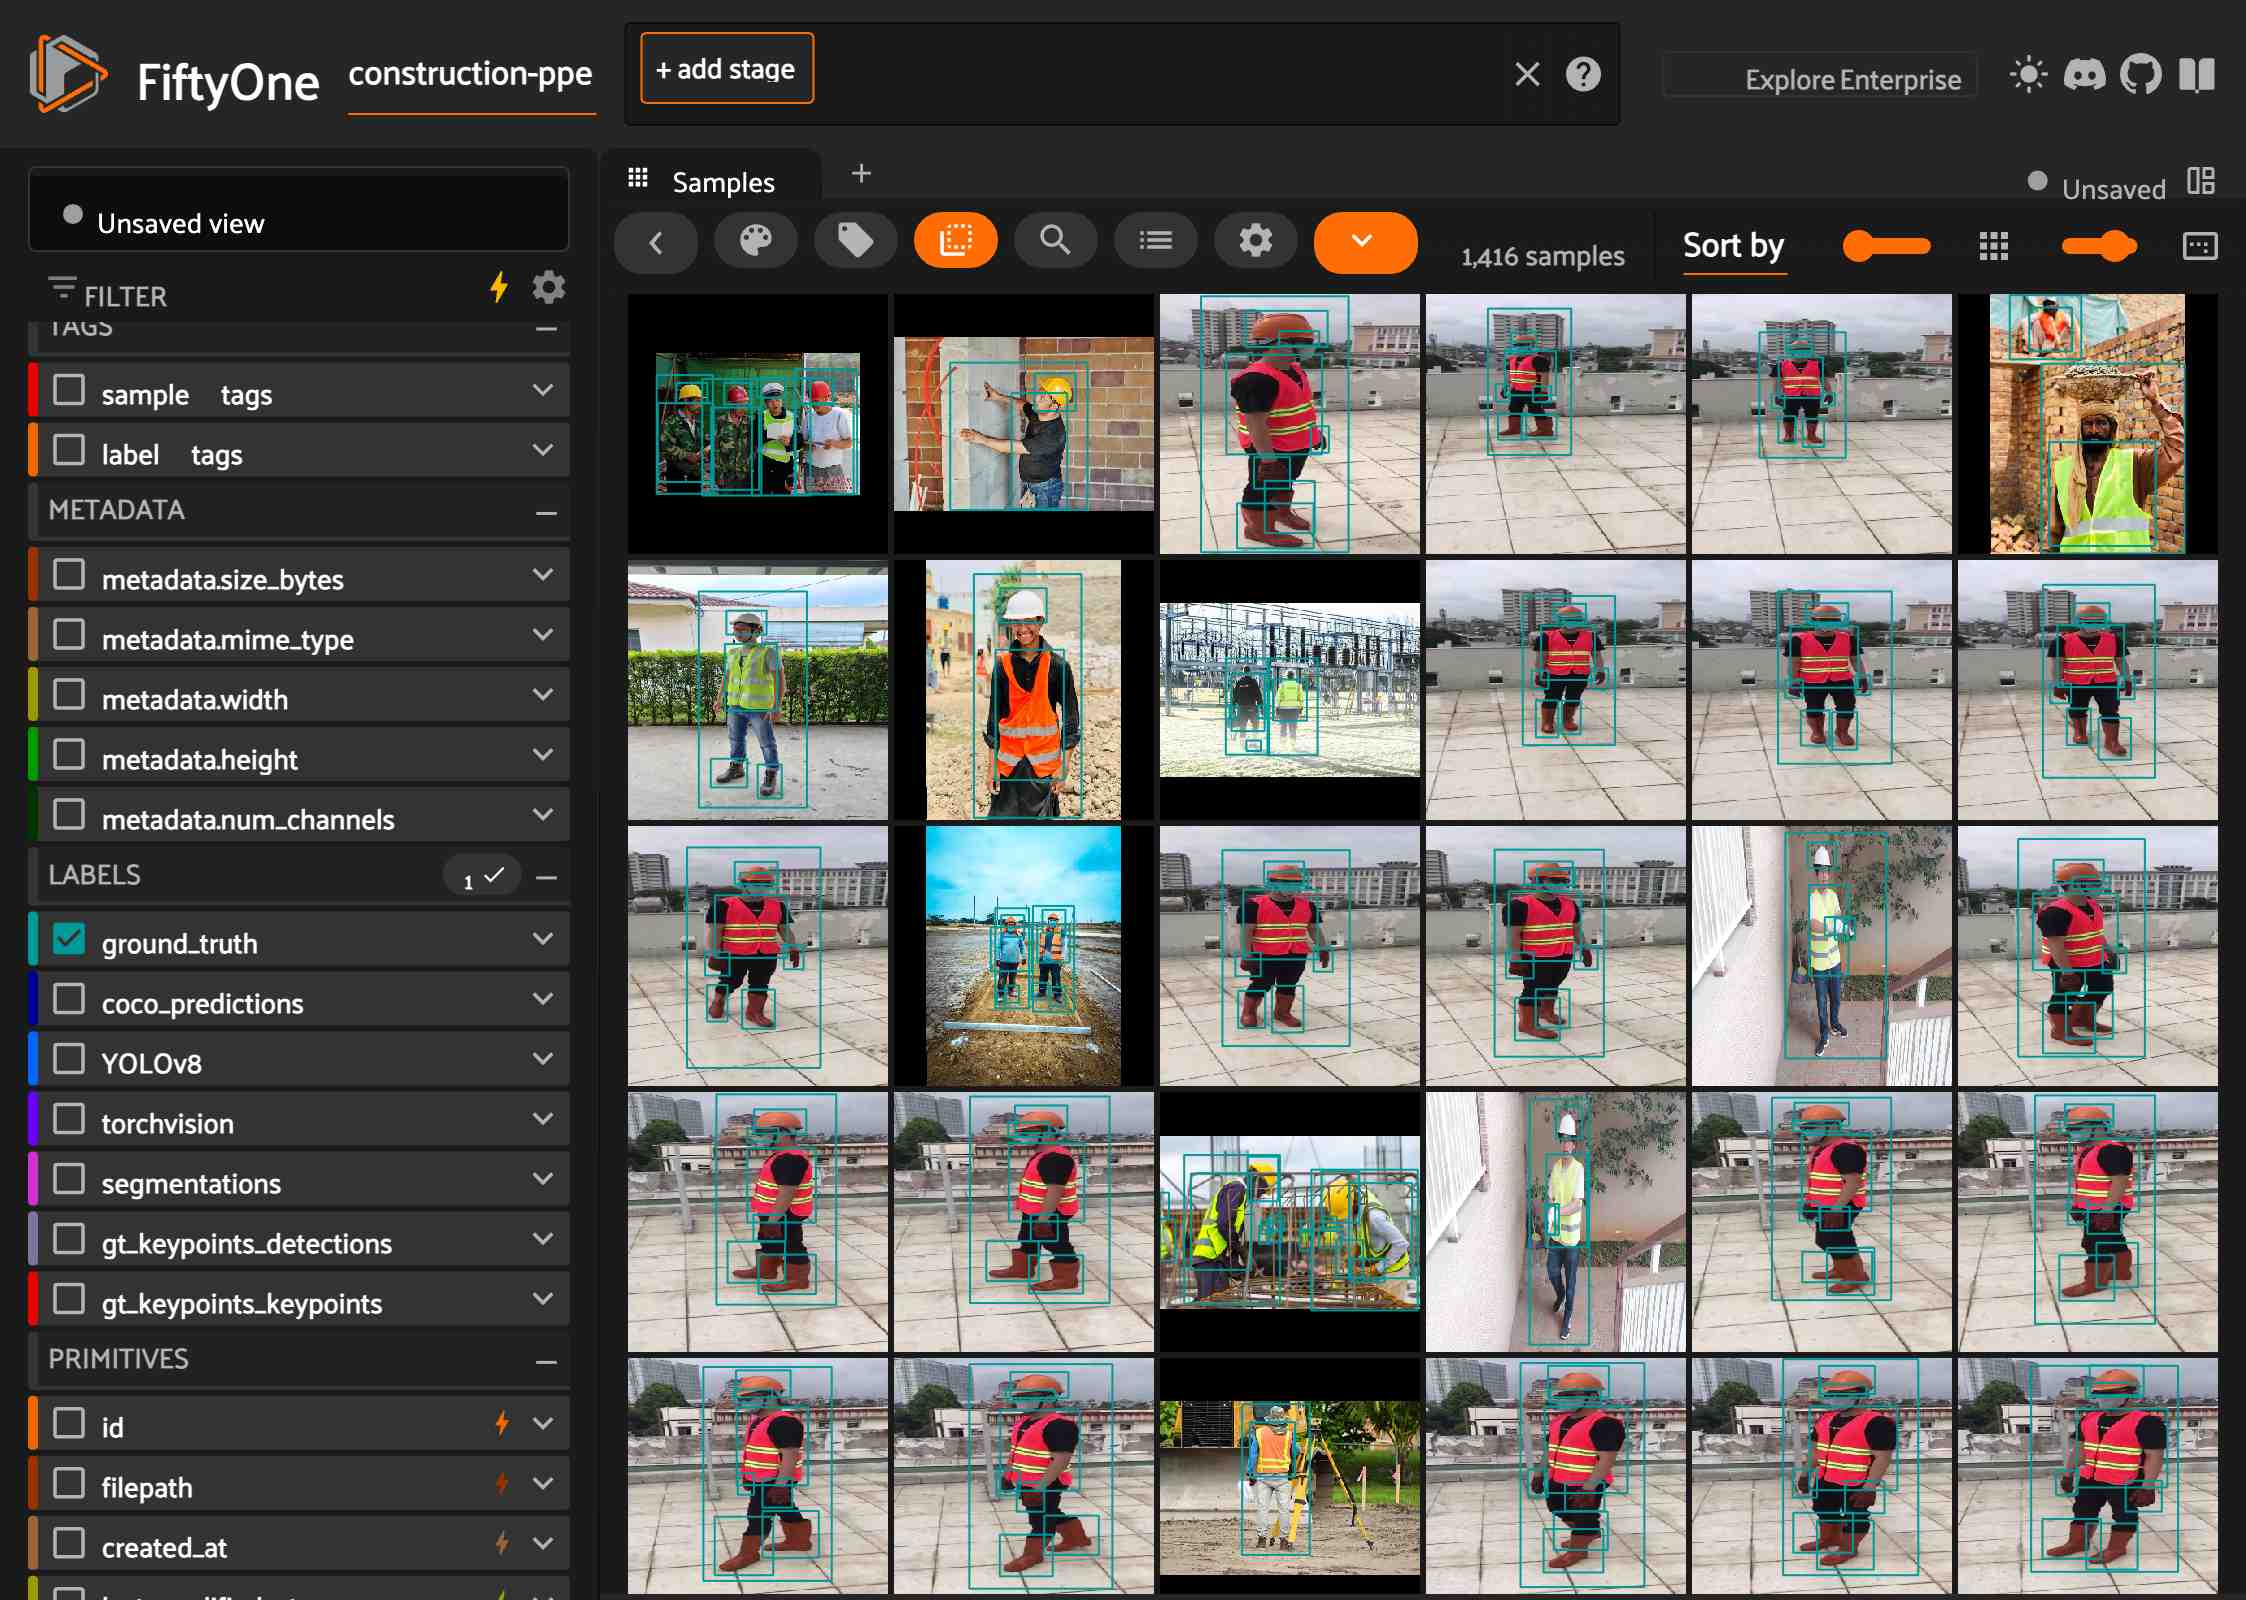

In [ ]:
session = fo.launch_app(dataset)

/Users/hassanbadawy/Documents/01_Code/RedHat/ppe-lab/datasets/construction-ppe/images/train/image100.jpg
  helmet: [0.370235, 0.34187449999999997, 0.101734, 0.082469]
  helmet: [0.186031, 0.34187449999999997, 0.119266, 0.078141]
  Person: [0.1105, 0.31179700000000005, 0.216234, 0.4565]


@dataset{Dalvi_Construction_PPE_Dataset_2025,
    author    = {Mrunmayee Dalvi and Niyati Singh and Sahil Bhingarde and Ketaki Chalke},
    title     = {Construction-PPE: Personal Protective Equipment Detection Dataset},
    month     = {January},
    year      = {2025},
    version   = {1.0.0},
    license   = {AGPL-3.0},
    url       = {https://docs.ultralytics.com/datasets/detect/construction-ppe/},
    publisher = {Ultralytics}
}